# 🏥 Hospital Stay Cost Prediction Using Machine Learning


# 1. Problem Statement & Objective

## Problem Statement

Hospitals often need to estimate the treatment cost of a patient before admission. Accurate cost prediction helps hospital management in budgeting and allows patients to plan their medical expenses.

In this project, we use **Machine Learning (Linear Regression)** to predict the **Hospital Stay Cost** based on patient-related information.

---

## Objective

The main objective of this project is to build a **Linear Regression model** that predicts the hospital stay cost using patient details available in the dataset.

---

## Features (Independent Variables - X)

Features are the input variables that help the model make predictions. These variables influence the hospital stay cost.

Examples:
- Age
- Gender
- Department
- Length of Stay
- Surgery
- Insurance
- Room Type
- Previous Admissions

---

## Target Variable (Dependent Variable - y)

The target variable is the output that we want to predict.

Target:
- **Hospital Stay Cost**

---



# First, we defined our problem statement. Our objective is to predict the Hospital Stay Cost using patient-related features

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset
df = pd.read_csv("Hospital_Stay_Cost_Dataset.csv")

# Display first five records
df.head()

,Record_ID,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column
0,1,46,M,Cardiology,11,True,False,General,5,65524
1,2,21,M,Orthopedics,12,True,False,Private,1,127041
2,3,71,M,ICU,9,True,True,Private,4,119856
3,4,53,M,Orthopedics,5,True,False,General,2,53649
4,5,62,F,Cardiology,2,False,True,General,5,21763


In [2]:

# Import Libraries

import pandas as pd              # Data manipulation
import numpy as np               # Numerical computations
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns            # Statistical visualization

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("Hospital_Stay_Cost_Dataset.csv")

# Display first five rows
df.head()

,Record_ID,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column
0,1,46,M,Cardiology,11,True,False,General,5,65524
1,2,21,M,Orthopedics,12,True,False,Private,1,127041
2,3,71,M,ICU,9,True,True,Private,4,119856
3,4,53,M,Orthopedics,5,True,False,General,2,53649
4,5,62,F,Cardiology,2,False,True,General,5,21763



## Observation

After performing Data Understanding, we can identify:

- Total number of records.
- Number of features.
- Numerical and categorical variables.
- Incorrect data types.
- Missing values.
- Statistical characteristics of the dataset.

This information helps us perform proper Data Cleaning and Data Preprocessing in the next step.

# After loading the dataset, we performed data understanding to check the dataset structure, columns and data types. This helped us understand the data before performing cleaning and analysis

In [3]:


# Display first 5 rows
print("First 5 Rows")
display(df.head())

# Display last 5 rows
print("Last 5 Rows")
display(df.tail())

# Shape of Dataset
print("Shape of Dataset")
print(df.shape)

# Column Names
print("\nColumn Names")
print(df.columns)

# Dataset Information
print("\nDataset Information")
df.info()

# Data Types
print("\nData Types")
print(df.dtypes)

# Statistical Summary
print("\nStatistical Summary")
display(df.describe())

# Number of Rows and Columns
rows, cols = df.shape

print(f"\nTotal Rows    : {rows}")
print(f"Total Columns : {cols}")

First 5 Rows


,Record_ID,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column
0,1,46,M,Cardiology,11,True,False,General,5,65524
1,2,21,M,Orthopedics,12,True,False,Private,1,127041
2,3,71,M,ICU,9,True,True,Private,4,119856
3,4,53,M,Orthopedics,5,True,False,General,2,53649
4,5,62,F,Cardiology,2,False,True,General,5,21763


Last 5 Rows


,Record_ID,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column
495,496,73,M,Orthopedics,11,False,True,General,0,39236
496,497,27,M,Orthopedics,8,False,True,Private,2,71867
497,498,67,F,ICU,9,True,False,General,3,65857
498,499,18,M,Neurology,6,False,True,General,0,37525
499,500,56,M,General,12,False,True,General,3,44497


Shape of Dataset
(500, 10)

Column Names
Index(['Record_ID', 'Age', 'Gender', 'Department', 'Length_of_Stay', 'Surgery',
       'Insurance', 'Room_Type', 'Previous_Admissions', 'Target_Column'],
      dtype='str')

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Record_ID            500 non-null    int64
 1   Age                  500 non-null    int64
 2   Gender               500 non-null    str  
 3   Department           500 non-null    str  
 4   Length_of_Stay       500 non-null    int64
 5   Surgery              500 non-null    bool 
 6   Insurance            500 non-null    bool 
 7   Room_Type            500 non-null    str  
 8   Previous_Admissions  500 non-null    int64
 9   Target_Column        500 non-null    int64
dtypes: bool(2), int64(5), str(3)
memory usage: 32.4 KB

Data Types
Record_ID              int6

,Record_ID,Age,Length_of_Stay,Previous_Admissions,Target_Column
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,250.500000,51.468000,7.87000,2.476000,65495.720000
std,144.481833,19.211641,4.18427,1.710929,31751.175423
min,1.000000,18.000000,1.00000,0.000000,10022.000000
25%,125.750000,34.000000,4.00000,1.000000,42763.750000
50%,250.500000,52.000000,8.00000,2.000000,59518.000000
75%,375.250000,68.000000,11.00000,4.000000,81894.500000
max,500.000000,85.000000,15.00000,5.000000,167502.000000



Total Rows    : 500
Total Columns : 10


## Observation

- The dataset contains **500 records** and multiple features.
- It includes both **numerical** and **categorical** variables.
- The target variable is **Hospital Stay Cost**, which is continuous.
- The dataset structure has been successfully examined using Pandas functions.
- This understanding helps in identifying the preprocessing steps required before model training.


## Observation

After completing the Data Quality Check, we ensure that:

- Missing values are handled.
- Duplicate records are removed.
- Data types are correct.
- Invalid values are identified.
- Outliers are detected.

Clean and consistent data improves the performance, reliability, and accuracy of the Machine Learning model.

In [4]:

# Check Missing Values
print("Missing Values")
print(df.isnull().sum())

# Check Duplicate Records
print("\nDuplicate Records")
print(df.duplicated().sum())

# Remove Duplicate Records (if any)
df.drop_duplicates(inplace=True)

# Check Data Types
print("\nData Types")
print(df.dtypes)

# Check Dataset Shape After Removing Duplicates
print("\nDataset Shape")
print(df.shape)

# Check Statistical Summary
print("\nStatistical Summary")
display(df.describe())

Missing Values
Record_ID              0
Age                    0
Gender                 0
Department             0
Length_of_Stay         0
Surgery                0
Insurance              0
Room_Type              0
Previous_Admissions    0
Target_Column          0
dtype: int64

Duplicate Records
0

Data Types
Record_ID              int64
Age                    int64
Gender                   str
Department               str
Length_of_Stay         int64
Surgery                 bool
Insurance               bool
Room_Type                str
Previous_Admissions    int64
Target_Column          int64
dtype: object

Dataset Shape
(500, 10)

Statistical Summary


,Record_ID,Age,Length_of_Stay,Previous_Admissions,Target_Column
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,250.500000,51.468000,7.87000,2.476000,65495.720000
std,144.481833,19.211641,4.18427,1.710929,31751.175423
min,1.000000,18.000000,1.00000,0.000000,10022.000000
25%,125.750000,34.000000,4.00000,1.000000,42763.750000
50%,250.500000,52.000000,8.00000,2.000000,59518.000000
75%,375.250000,68.000000,11.00000,4.000000,81894.500000
max,500.000000,85.000000,15.00000,5.000000,167502.000000


 # After understanding the data, we performed data cleaning. We checked missing values, duplicate records, data types and outliers to make the dataset clean and suitable for further analysis and model building

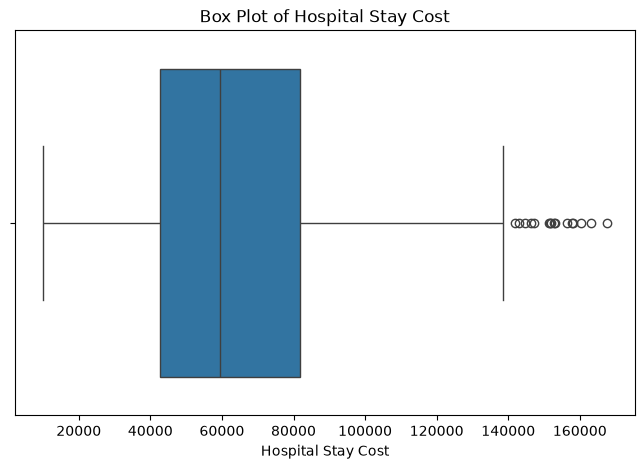

In [5]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Target_Column"])

plt.title("Box Plot of Hospital Stay Cost")
plt.xlabel("Hospital Stay Cost")

plt.show()

In [6]:

Q1 = df["Target_Column"].quantile(0.25)
Q3 = df["Target_Column"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Target_Column"] < lower_limit) |
    (df["Target_Column"] > upper_limit)
]

print("Number of Outliers :", len(outliers))

display(outliers.head())

Number of Outliers : 16


,Record_ID,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column
8,9,49,M,ICU,15,True,True,Private,3,167502
32,33,71,F,General,15,True,True,Private,1,152686
72,73,33,M,General,14,True,True,Private,4,151882
78,79,42,M,Orthopedics,15,False,True,Private,5,141928
180,181,46,F,General,15,True,False,Private,0,153005


## Observation

- No missing values were found (or handled if present).
- Duplicate records were checked and removed if necessary.
- The dataset contains appropriate data types for most columns.
- Outliers were identified using a Box Plot and the IQR method.
- The dataset is now cleaner and ready for Exploratory Data Analysis (EDA).


# Observation

After completing EDA, we understand:

- Distribution of numerical features.
- Frequency of categorical features.
- Relationships between variables.
- Correlation among numerical columns.
- Presence of outliers and unusual patterns.

These insights help in selecting appropriate preprocessing techniques and building a better Machine Learning model.

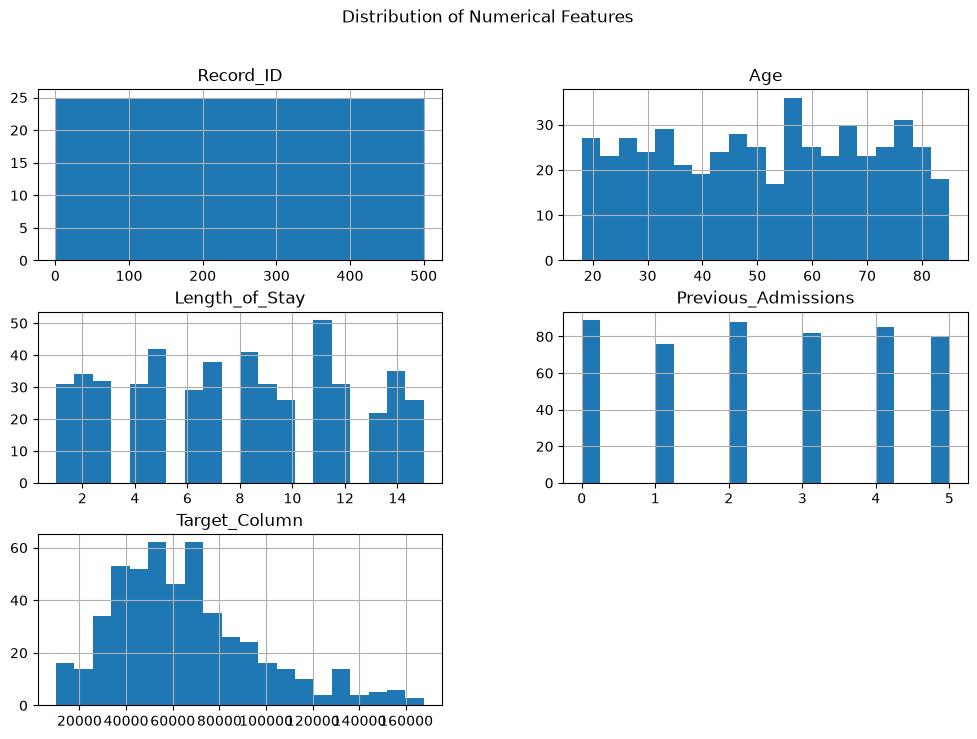

In [7]:


numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numerical_columns].hist(figsize=(12,8), bins=20)

plt.suptitle("Distribution of Numerical Features")

plt.show()

In [8]:
==

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(x=df[column])

    plt.title(f"Count Plot of {column}")

    plt.xticks(rotation=45)

    plt.show()

SyntaxError: invalid syntax (4259643569.py, line 1)

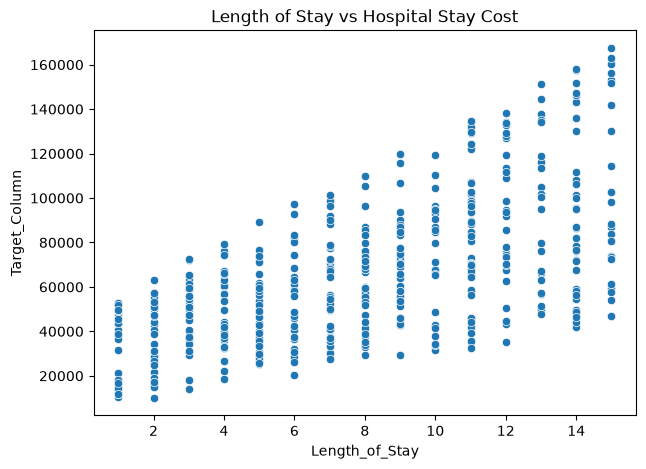

In [ ]:

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Length_of_Stay"],
    y=df["Target_Column"]
)

plt.title("Length of Stay vs Hospital Stay Cost")

plt.show()

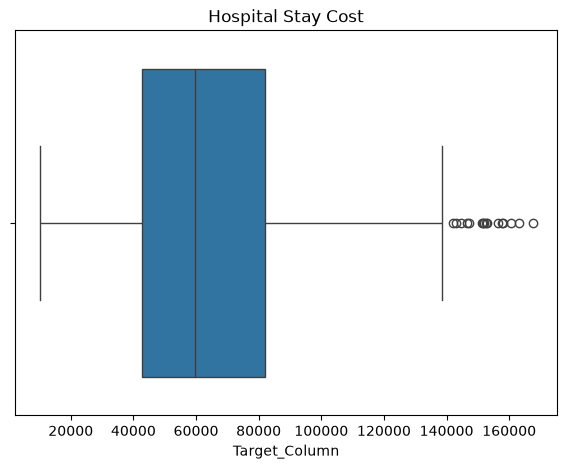

In [ ]:


plt.figure(figsize=(7,5))

sns.boxplot(x=df["Target_Column"])

plt.title("Hospital Stay Cost")

plt.show()

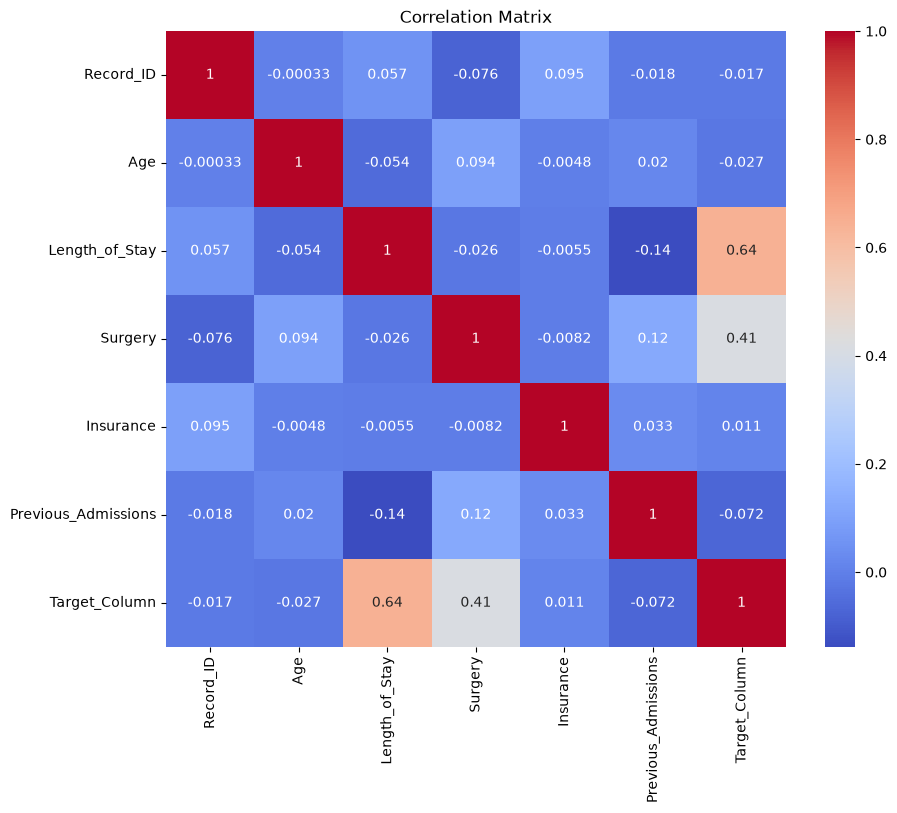

In [ ]:


plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Observation

- Histograms show the distribution of numerical variables.
- Count plots display the frequency of each category.
- Scatter plots reveal relationships between numerical features and Hospital Stay Cost.
- Box plots help identify potential outliers.
- The correlation heatmap highlights strong and weak relationships among numerical variables.
- EDA provides valuable insights that guide preprocessing and model selection.

# After data cleaning, we performed Exploratory Data Analysis to understand the distribution, patterns and relationships between different variables. We used different plots such as histogram, count plot, scatter plot, box plot and correlation heatmap


## Observation

In this project, Feature Engineering is minimal because the dataset already contains relevant features.

Only unnecessary columns are removed, and optional derived features can be created if required.

In [ ]:

# Drop Record_ID if it exists

if "Record_ID" in df.columns:
    df.drop("Record_ID", axis=1, inplace=True)

print("Updated Columns:")
print(df.columns)

NameError: name 'df' is not defined

In [ ]:


# Create Cost_per_Day feature

df["Cost_per_Day"] = df["Target_Column"] / df["Length_of_Stay"]

# Display first few rows

df.head()

,Age,Gender,Department,Length_of_Stay,Surgery,Insurance,Room_Type,Previous_Admissions,Target_Column,Cost_per_Day
0,46,M,Cardiology,11,True,False,General,5,65524,5956.727273
1,21,M,Orthopedics,12,True,False,Private,1,127041,10586.750000
2,71,M,ICU,9,True,True,Private,4,119856,13317.333333
3,53,M,Orthopedics,5,True,False,General,2,53649,10729.800000
4,62,F,Cardiology,2,False,True,General,5,21763,10881.500000


## Observation

- Unnecessary identifier columns (such as Record_ID) were removed because they do not contribute to prediction.
- A new feature, **Cost_per_Day**, was created by dividing the total hospital stay cost by the length of stay.
- Feature Engineering helps improve the quality of input data and can enhance the performance of the Machine Learning model.
- For this dataset, only minimal feature engineering was required because most features were already meaningful.


# Observation

After preprocessing:

- Features (X) and Target (y) were separated.
- Categorical variables were encoded.
- The dataset was split into training and testing sets.
- The data is now ready for Machine Learning model training.

In [ ]:

# Features (Independent Variables)
X = df.drop("Target_Column", axis=1)

# Target Variable (Dependent Variable)
y = df["Target_Column"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (500, 9)
Target Shape : (500,)


In [ ]:


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    X[column] = le.fit_transform(X[column])

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


C:\Users\Sanika\AppData\Local\Temp\ipykernel_29408\2637857147.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [ ]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (400, 9)
Testing Features : (100, 9)
Training Target : (400,)
Testing Target : (100,)


In [ ]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


## Observation

- The dataset was successfully divided into **Features (X)** and **Target (y)**.
- All categorical variables were converted into numerical values using **Label Encoding**.
- The dataset was split into **80% training data** and **20% testing data**.
- Feature Scaling was applied using **StandardScaler** to normalize numerical features (optional for Linear Regression).
- The preprocessed data is now ready for training the Machine Learning model.

 # After EDA, we prepared the data for machine learning. We separated the input features and target variable and converted the data into a suitable format for model training and testing


# Observation

After training:

- The Linear Regression model has successfully learned the relationship between the input features and Hospital Stay Cost.
- The model is now ready to predict the cost for new patients.
- In the next step, we will evaluate the model's performance using different evaluation metrics.

In [ ]:


from sklearn.linear_model import LinearRegression

# Create Linear Regression Model
model = LinearRegression()

print("Linear Regression Model Created Successfully.")

Linear Regression Model Created Successfully.


In [ ]:


# Train the model
model.fit(X_train, y_train)

print("Model Training Completed Successfully.")

Model Training Completed Successfully.


In [ ]:

print("Intercept")
print(model.intercept_)

print("\nCoefficients")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature} : {coefficient}")

Intercept
-9099.553552587851

Coefficients
Age : -5.341171162280057
Gender : -1303.7150576743813
Department : 1167.7563620379162
Length_of_Stay : 5857.926360599623
Surgery : 21884.382372873024
Insurance : 1020.733897903021
Room_Type : 7408.271541836901
Previous_Admissions : -1010.5110782805168
Cost_per_Day : 0.9718234253944047


## Observation

- A Linear Regression model was successfully created.
- The model was trained using the training dataset.
- During training, the model learned the relationship between the input features and the target variable.
- The coefficients indicate the contribution of each feature toward predicting the Hospital Stay Cost.
- The intercept represents the predicted cost when all feature values are zero.
- The trained model is now ready to make predictions on the testing dataset.

# # After preprocessing, we selected Linear Regression as our machine learning algorithm. We trained the model using the training dataset so that it could learn the relationship between the input features and Hospital Stay Cost.

In [ ]:


# Predict Hospital Stay Cost

y_pred = model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.



# Observation

After evaluation:

- Predictions are generated for the testing dataset.
- Model performance is measured using MAE, MSE, RMSE and R² Score.
- Lower MAE, MSE and RMSE indicate better prediction accuracy.
- Higher R² Score indicates that the model explains the data more effectively.

In [ ]:


comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
361,14417,22519.046006
73,77579,48779.830762
374,17045,5247.998662
155,13733,23746.693309
104,74473,84274.363642
394,42323,57026.119220
377,45626,61814.238276
124,95467,113036.745498
68,133347,98834.264962
450,46224,60140.614039


In [ ]:


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)

Mean Absolute Error (MAE): 15650.682943251866
Mean Squared Error (MSE): 390262745.76247233
Root Mean Squared Error (RMSE): 19755.068862508993
R² Score: 0.6568253602630647


In [ ]:


print("Model Evaluation Summary")

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

Model Evaluation Summary
MAE  : 15650.68
MSE  : 390262745.76
RMSE : 19755.07
R²   : 0.6568


# # After training the model, we predicted Hospital Stay Cost on the testing data. We evaluated the model using MAE, MSE, RMSE and R² score to measure its prediction performance.

## Observation

- The trained Linear Regression model successfully predicted the Hospital Stay Cost for the testing dataset.
- The predicted values were compared with the actual values to measure the model's performance.
- **MAE** indicates the average prediction error.
- **MSE** penalizes larger errors more heavily.
- **RMSE** expresses the prediction error in the same unit as the target variable.
- **R² Score** shows how well the model explains the variation in Hospital Stay Cost.
- A lower MAE, MSE, and RMSE, along with a higher R² Score, indicates better model performance and prediction accuracy.

# new model train 


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("target_column", axis=1)
y = df["target_column"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'df' is not defined


# Observation

After interpreting the model:

- The relationship between actual and predicted values becomes clear.
- Residual analysis shows whether prediction errors are random.
- Feature coefficients identify the most influential variables.
- Error analysis helps understand the strengths and weaknesses of the model.

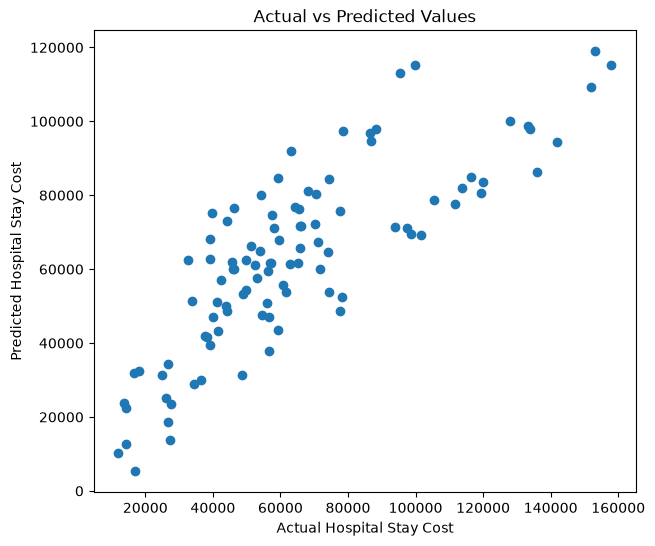

In [ ]:


plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Hospital Stay Cost")
plt.ylabel("Predicted Hospital Stay Cost")
plt.title("Actual vs Predicted Values")

plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("Hospital_Stay_Cost_Dataset.csv")

print(df.head())
print(df.columns)

   Record_ID  Age Gender   Department  Length_of_Stay  Surgery  Insurance  \
0          1   46      M   Cardiology              11     True      False   
1          2   21      M  Orthopedics              12     True      False   
2          3   71      M          ICU               9     True       True   
3          4   53      M  Orthopedics               5     True      False   
4          5   62      F   Cardiology               2    False       True   

  Room_Type  Previous_Admissions  Target_Column  
0   General                    5          65524  
1   Private                    1         127041  
2   Private                    4         119856  
3   General                    2          53649  
4   General                    5          21763  
Index(['Record_ID', 'Age', 'Gender', 'Department', 'Length_of_Stay', 'Surgery',
       'Insurance', 'Room_Type', 'Previous_Admissions', 'Target_Column'],
      dtype='str')


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Remove Record_ID
if "Record_ID" in df.columns:
    df = df.drop("Record_ID", axis=1)

# Separate features and target
X = df.drop("Target_Column", axis=1)
y = df["Target_Column"]

# Encode categorical columns
le = LabelEncoder()

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    X[column] = le.fit_transform(X[column])

print("Categorical columns encoded successfully.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Categorical columns encoded successfully.
X_train: (400, 8)
X_test: (100, 8)
y_train: (400,)
y_test: (100,)


C:\Users\Sanika\AppData\Local\Temp\ipykernel_13964\384235074.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [4]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Make predictions
decision_tree_pred = decision_tree_model.predict(X_test)

print("Decision Tree Regressor trained successfully!")

Decision Tree Regressor trained successfully!


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, decision_tree_pred)
mse = mean_squared_error(y_test, decision_tree_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, decision_tree_pred)

# Display results
print("Decision Tree Regressor Evaluation")
print("-----------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Decision Tree Regressor Evaluation
-----------------------------------
MAE  : 7454.25
MSE  : 84849687.83
RMSE : 9211.39
R²   : 0.9254


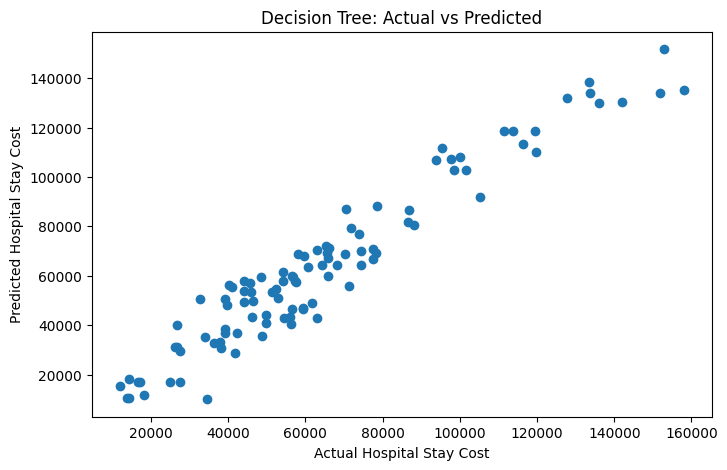

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, decision_tree_pred)

plt.xlabel("Actual Hospital Stay Cost")
plt.ylabel("Predicted Hospital Stay Cost")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

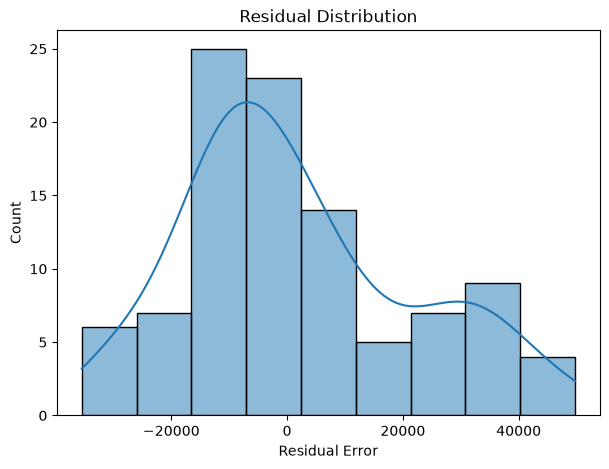

In [ ]:


residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

In [ ]:


coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,Surgery,21884.382373
6,Room_Type,7408.271542
3,Length_of_Stay,5857.926361
2,Department,1167.756362
5,Insurance,1020.733898
8,Cost_per_Day,0.971823
0,Age,-5.341171
7,Previous_Admissions,-1010.511078
1,Gender,-1303.715058


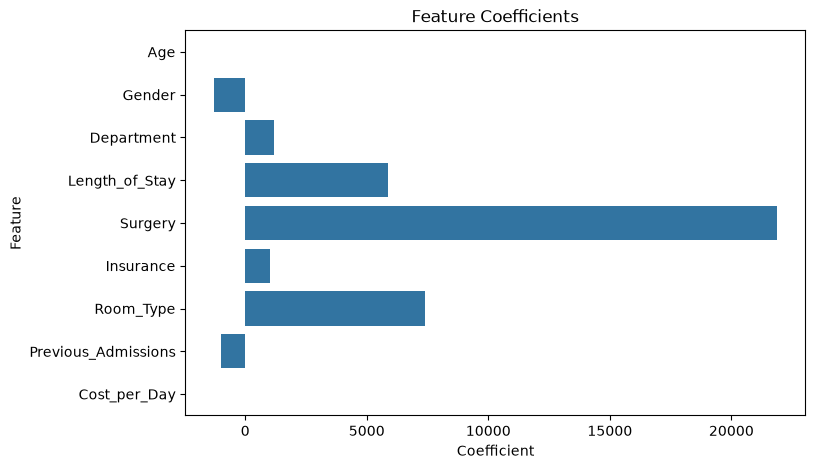

In [ ]:


plt.figure(figsize=(8,5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Coefficients")

plt.show()

# After evaluating the model, we performed model interpretation to understand the prediction behavior. We used Actual vs Predicted values, Residual Analysis and Feature Coefficients to understand errors and feature influence

## Observation

- The **Actual vs Predicted** plot shows how closely the predicted values match the actual Hospital Stay Cost.
- The **Residual Distribution** indicates whether prediction errors are randomly distributed around zero.
- The **Feature Coefficients** reveal the impact of each feature on the prediction.
- Features with larger positive or negative coefficients have a greater influence on the Hospital Stay Cost.
- Model interpretation provides confidence in the model's predictions and helps identify areas for future improvement.


# Observation

After completing this step:

- The trained model is successfully saved.
- The saved model can be loaded whenever required.
- New patient data can be used to make predictions.
- The model is ready for deployment in real-world applications.

In [ ]:


import joblib

# Save the trained model
joblib.dump(model, "Hospital_Cost_Model.pkl")

print("Model saved successfully as Hospital_Cost_Model.pkl")

Model saved successfully as Hospital_Cost_Model.pkl


In [ ]:


loaded_model = joblib.load("Hospital_Cost_Model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:


# Example: Predict using first patient from test data
new_prediction = loaded_model.predict(X_test.iloc[:1])

print("Predicted Hospital Stay Cost:")
print(new_prediction)

Predicted Hospital Stay Cost:
[22519.04600614]


In [ ]:


actual_value = y_test.iloc[0]

predicted_value = loaded_model.predict(X_test.iloc[:1])[0]

print("Actual Hospital Stay Cost   :", actual_value)
print("Predicted Hospital Stay Cost:", predicted_value)

Actual Hospital Stay Cost   : 14417
Predicted Hospital Stay Cost: 22519.046006142285


# Finally, we saved the trained model using Joblib so that it could be reused without retraining. We then loaded the saved model and used new patient data to predict the Hospital Stay Cost.

## Observation

- The trained Linear Regression model was successfully saved using the **joblib** library.
- The saved model was loaded without retraining.
- Predictions were generated for new patient data using the loaded model.
- The predicted Hospital Stay Cost was compared with the actual value.
- Saving the model makes it reusable and suitable for deployment in real-world healthcare applications.

# In conclusion, we developed a Linear Regression model to predict Hospital Stay Cost. The trained model can be saved and reused for new patient predictions. In future, it can be integrated into applications such as Streamlit, Flask or cloud-based systems



By completing these steps, a complete end-to-end Machine Learning pipeline was developed for predicting **Hospital Stay Cost** using the **Linear Regression** algorithm.

In [3]:


import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("Hospital_Stay_Cost_Dataset.csv")

# Remove Record_ID if available
if "Record_ID" in df.columns:
    df = df.drop("Record_ID", axis=1)

# IMPORTANT:
# Do NOT create Cost_per_Day because it uses the target value.

# Separate Features and Target
X = df.drop("Target_Column", axis=1)
y = df["Target_Column"]

# Save encoders for categorical columns
encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    encoders[column] = le

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "Hospital_Cost_Model.pkl")

# Save encoders
joblib.dump(encoders, "Hospital_Cost_Encoders.pkl")

print("Model saved successfully!")
print("Hospital_Cost_Model.pkl")
print("Hospital_Cost_Encoders.pkl")

Model saved successfully!
Hospital_Cost_Model.pkl
Hospital_Cost_Encoders.pkl


C:\Users\Sanika\AppData\Local\Temp\ipykernel_20948\1934161668.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Hospital_Stay_Cost_Dataset.csv")

if "Record_ID" in df.columns:
    df = df.drop("Record_ID", axis=1)

X = df.drop("Target_Column", axis=1)
y = df["Target_Column"]

encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    encoders[column] = encoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

joblib.dump(model, "Hospital_Cost_Model.pkl")
joblib.dump(encoders, "Hospital_Cost_Encoders.pkl")

print("Model and encoders saved successfully!")
print("Categorical columns:", list(categorical_columns))

Model and encoders saved successfully!
Categorical columns: ['Gender', 'Department', 'Room_Type']


C:\Users\Sanika\AppData\Local\Temp\ipykernel_22604\406517389.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [5]:
df.columns.tolist()

['Age',
 'Gender',
 'Department',
 'Length_of_Stay',
 'Surgery',
 'Insurance',
 'Room_Type',
 'Previous_Admissions',
 'Target_Column']

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Target_Column", axis=1)
y = df["Target_Column"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
import joblib

joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']